<a href="https://colab.research.google.com/github/fathimashafna362-cmyk/ADD_ON_COURSE/blob/main/day_4_task_using_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import zipfile
with zipfile.ZipFile("/content/emotions.zip", "r") as zip_ref:
    zip_ref.extractall()

print("Dataset Extracted Successfully")

Dataset Extracted Successfully


In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing import image

In [ ]:
train_dataset = tf.keras.preprocessing.image_dataset_from_directory("/content/emotions",
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(128,128),
    batch_size=8
)

val_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/emotions",
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(128,128),
    batch_size=8
)
class_names = train_dataset.class_names

print(class_names)

Found 40 files belonging to 4 classes.
Using 32 files for training.
Found 40 files belonging to 4 classes.
Using 8 files for validation.
['angry', 'sad', 'smile', 'tensed']


In [ ]:
model = tf.keras.Sequential([

    tf.keras.layers.Rescaling(1./255,input_shape=(128,128,3)),

    tf.keras.layers.Conv2D(32,(3,3),activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64,(3,3),activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128,(3,3),activation="relu"),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128,activation="relu"),

    tf.keras.layers.Dense(4,activation="softmax")

])

model.summary()

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,156 (12.61 MB)

 Trainable params: 3,305,156 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10
)

model.save("emotion_model.keras")

print("Model Saved")

Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 387ms/step - accuracy: 0.2812 - loss: 1.7130 - val_accuracy: 0.2500 - val_loss: 1.4236
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 293ms/step - accuracy: 0.2500 - loss: 1.4122 - val_accuracy: 0.3750 - val_loss: 1.3747
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 293ms/step - accuracy: 0.2812 - loss: 1.3712 - val_accuracy: 0.2500 - val_loss: 1.3588
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 289ms/step - accuracy: 0.4688 - loss: 1.3126 - val_accuracy: 0.2500 - val_loss: 1.3446
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 306ms/step - accuracy: 0.6562 - loss: 1.2049 - val_accuracy: 0.3750 - val_loss: 1.3202
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 281ms/step - accuracy: 0.5625 - loss: 1.0927 - val_accuracy: 0.3750 - val_loss: 1.4584
Epoch 7/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 277ms/step - accuracy: 0.5938 - loss: 1.0317 - val_accuracy: 0.3750 - val_loss: 1.2321
Epoch 8/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 441ms/step - accuracy: 0.7812 - loss: 0.7481 - val_accuracy: 0.3750 - val_loss:

In [ ]:
from google.colab import files

uploaded = files.upload()


Saving smillingss.jpg to smillingss (1).jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Predicted Emotion : smile
Confidence : 49.19 %


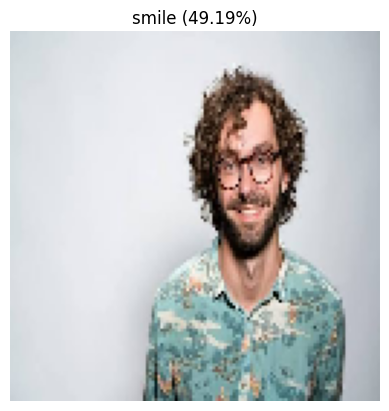

In [ ]:
img_path = list(uploaded.keys())[0]

img = image.load_img(img_path, target_size=(128,128))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array/255.0

prediction = model.predict(img_array)

predicted_class = class_names[np.argmax(prediction)]
confidence = np.max(prediction)*100

print("Predicted Emotion :", predicted_class)
print("Confidence :", round(confidence,2),"%")

plt.imshow(img)
plt.title(f"{predicted_class} ({confidence:.2f}%)")
plt.axis("off")
plt.show()